# Comparison and assignment discussion

In [29]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA

CLASSES = ["rest", "motor", "math", "memory"]
DATA_DIR = "Preprocessed data"
RESULTS_DIR = "results"


## Load saved deep-model metrics

In [30]:
intra_path = os.path.join(RESULTS_DIR, "intra_results.json")
cross_path = os.path.join(RESULTS_DIR, "cross_results.json")

if not os.path.exists(intra_path) or not os.path.exists(cross_path):
    raise FileNotFoundError(
        "Run intra_classification.ipynb and cross_classification.ipynb first so results JSON files exist."
    )

with open(intra_path) as f:
    intra_results = json.load(f)
with open(cross_path) as f:
    cross_results = json.load(f)

print("Intra results:")
print(json.dumps(intra_results, indent=2))
print("\nCross results:")
print(json.dumps(cross_results, indent=2))


Intra results:
{
  "1D Feature CNN": 0.5625,
  "1D Feature CNN std": 0.05412658773652741,
  "1D Feature CNN ci95": 0.06125,
  "GAT": 0.546875,
  "CNN-GAT": 0.421875,
  "EEGNet (bandpower)": 0.828125
}

Cross results:
{
  "1D Feature CNN": {
    "test1": 0.625,
    "test2": 0.4296875,
    "test3": 0.53125,
    "mean": 0.5286458333333334
  },
  "EEGNet (raw)": {
    "test1": 0.5234375,
    "test2": 0.484375,
    "test3": 0.578125,
    "mean": 0.5286458333333334
  },
  "EEGNet (bandpower)": {
    "test1": 0.453125,
    "test2": 0.328125,
    "test3": 0.3671875,
    "mean": 0.3828125
  },
  "GAT": {
    "test1": 0.390625,
    "test2": 0.375,
    "test3": 0.265625,
    "mean": 0.34375
  },
  "CNN-GAT": {
    "test1": 0.3359375,
    "test2": 0.328125,
    "test3": 0.3984375,
    "mean": 0.3541666666666667
  }
}


## Classical ML baseline (window-level protocol)

In [31]:

rows = []

rows.append({
    "Model": "1D Feature CNN",
    "Intra acc": intra_results.get("1D Feature CNN"),
    "Cross acc (mean)": cross_results.get("1D Feature CNN", {}).get("mean"),
    "Eval unit": "window",
    "Coverage": "intra+cross",
})

for name in ["GAT", "CNN-GAT", "EEGNet (raw)", "EEGNet (bandpower)"]:
    rows.append({
        "Model": name,
        "Intra acc": intra_results.get(name),
        "Cross acc (mean)": cross_results.get(name, {}).get("mean"),
        "Eval unit": "window",
        "Coverage": "intra+cross" if (intra_results.get(name) is not None and cross_results.get(name, {}).get("mean") is not None) else "partial",
    })

for _, r in classical_df.iterrows():
    rows.append({
        "Model": r["Model"],
        "Intra acc": r["Intra"],
        "Cross acc (mean)": r["CrossMean"],
        "Eval unit": "window",
        "Coverage": "intra+cross",
    })

results_table = pd.DataFrame(rows)
results_table


results_table_display = results_table.copy()
results_table_display[["Intra acc", "Cross acc (mean)"]] = results_table_display[["Intra acc", "Cross acc (mean)"]].apply(lambda col: col.map(lambda v: "—" if pd.isna(v) else v))
results_table_display


,Model,Intra acc,Cross acc (mean),Eval unit,Coverage
0,1D Feature CNN,0.5625,0.528646,window,intra+cross
1,GAT,0.546875,0.343750,window,intra+cross
2,CNN-GAT,0.421875,0.354167,window,intra+cross
3,EEGNet (raw),—,0.528646,window,partial
4,EEGNet (bandpower),0.828125,0.382812,window,intra+cross
5,SVM (RBF),0.515625,0.450521,window,intra+cross
6,Random Forest,0.484375,0.494792,window,intra+cross
7,LDA,0.625,0.455729,window,intra+cross


## Note on Missing Entries

`EEGNet (raw)` intra-subject result is shown as `—` because it was not run in the intra notebook pass; only cross-subject raw EEGNet was executed in the final pipeline.


## Visualizations

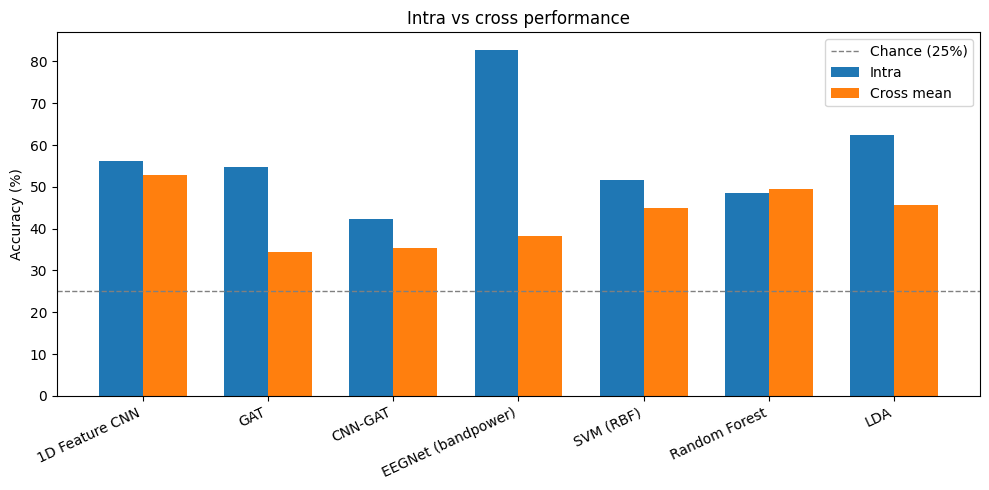

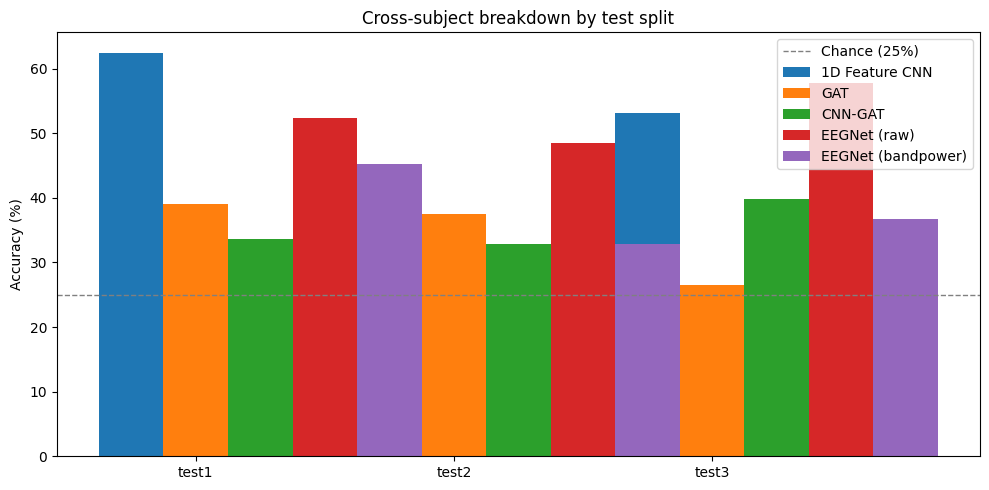

In [33]:
plot_df = results_table.dropna(subset=["Intra acc", "Cross acc (mean)"]).copy()
if not plot_df.empty:
    x = np.arange(len(plot_df))
    w = 0.35

    fig, ax = plt.subplots(figsize=(10, 5))
    b1 = ax.bar(x - w / 2, plot_df["Intra acc"] * 100, w, label="Intra")
    b2 = ax.bar(x + w / 2, plot_df["Cross acc (mean)"] * 100, w, label="Cross mean")

    ax.set_xticks(x)
    ax.set_xticklabels(plot_df["Model"], rotation=25, ha="right")
    ax.set_ylabel("Accuracy (%)")
    ax.set_title("Intra vs cross performance")
    ax.axhline(25, linestyle="--", color="gray", linewidth=1, label="Chance (25%)")
    ax.legend()
    plt.tight_layout()
    plt.show()

cross_detail = []
for model_name in ["1D Feature CNN", "GAT", "CNN-GAT", "EEGNet (raw)", "EEGNet (bandpower)"]:
    vals = cross_results.get(model_name, {})
    if vals:
        cross_detail.append(
            {
                "Model": model_name,
                "test1": vals.get("test1"),
                "test2": vals.get("test2"),
                "test3": vals.get("test3"),
            }
        )

if cross_detail:
    detail_df = pd.DataFrame(cross_detail)
    detail_df

    labels = ["test1", "test2", "test3"]
    x = np.arange(len(labels))
    w = 0.25

    fig, ax = plt.subplots(figsize=(10, 5))
    for i, (_, r) in enumerate(detail_df.iterrows()):
        accs = [r["test1"] * 100, r["test2"] * 100, r["test3"] * 100]
        ax.bar(x + (i - 1) * w, accs, w, label=r["Model"])

    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel("Accuracy (%)")
    ax.set_title("Cross-subject breakdown by test split")
    ax.axhline(25, linestyle="--", color="gray", linewidth=1, label="Chance (25%)")
    ax.legend()
    plt.tight_layout()
    plt.show()

## Intra vs cross-subject accuracy

Cross-subject accuracy is typically lower because the train and test distributions differ by participant. Inter-subject variability in sensor-level activity, oscillatory profiles, and noise structure introduces domain shift that is absent in intra-subject evaluation.

## Alternative approaches and train/val gap analysis

When the gap between training and validation/test accuracy increases, alternatives were introduced:
- **GAT**: imposes relational structure between sensors via attention on graph edges.
- **CNN-GAT**: combines temporal CNN extraction with graph attention for sensor interactions.
- **EEGNet (raw/bandpower)**: compact architecture designed for EEG/MEG-like signals, including a spectral-feature variant.
- **Classical ML baseline**: reference point for robustness and interpretability under the same window-level protocol.